In [28]:
import pandas as pd
import sqlite3

data = pd.read_csv('heart.csv')
conn = sqlite3.connect('heart_disease.db')
data.to_sql('patients', conn, if_exists='replace', index=False)

print("Done! Database created.")
print(f"Total rows: {len(data)}")

Done! Database created.
Total rows: 918


In [3]:
# How patients have HeartDisease?
query = """
SELECT 
    HeartDisease,
    COUNT(*) AS total_patients
FROM patients
GROUP BY HeartDisease
"""

result = pd.read_sql_query(query, conn)
print(result)

   HeartDisease  total_patients
0             0             410
1             1             508


In [4]:
# Total number of male and female that have HeartDisease
query1 = """
SELECT 
    Sex,
    HeartDisease,
    COUNT(*) AS total_patients
FROM patients
where HeartDisease = 1
GROUP BY Sex, HeartDisease
"""

result = pd.read_sql_query(query1, conn)
print(result)

  Sex  HeartDisease  total_patients
0   F             1              50
1   M             1             458


In [5]:
# How is min age for male and female that have HeartDisease?
query =""" 
select Sex,
min(Age) as min_age
from patients
where HeartDisease  = 1
group by Sex
"""
result = pd.read_sql_query(query, conn)
print(result)

  Sex  min_age
0   F       33
1   M       31


In [6]:
# Which chest pain type is most dangerous?
query =""" 
select ChestPainType,
COUNT(*) AS total,
    SUM(HeartDisease) AS has_disease
FROM patients
GROUP BY ChestPainType
ORDER BY has_disease DESC
"""
result = pd.read_sql_query(query, conn)
print(result)

  ChestPainType  total  has_disease
0           ASY    496          392
1           NAP    203           72
2           ATA    173           24
3            TA     46           20


In [7]:
#  Patients with high cholesterol above 250
query = """ 
select count(*) as patients_colesterol
from patients
where Cholesterol > 250
"""
result = pd.read_sql_query(query, conn)
print(result)

   patients_colesterol
0                  305


In [8]:
# Top 5 oldest patients with heart disease
query = """ 
select Age, Sex, ChestPainType, Cholesterol
from patients
where HeartDisease = 1
order by Age desc
limit 5
"""
result = pd.read_sql_query(query, conn)
print(result)

   Age Sex ChestPainType  Cholesterol
0   77   M           ASY          171
1   77   M           ASY          304
2   76   M           NAP          113
3   75   M           ASY          203
4   75   M           ASY          225


In [9]:
import pandas as pd
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
df.shape

(918, 12)

In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [12]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [13]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


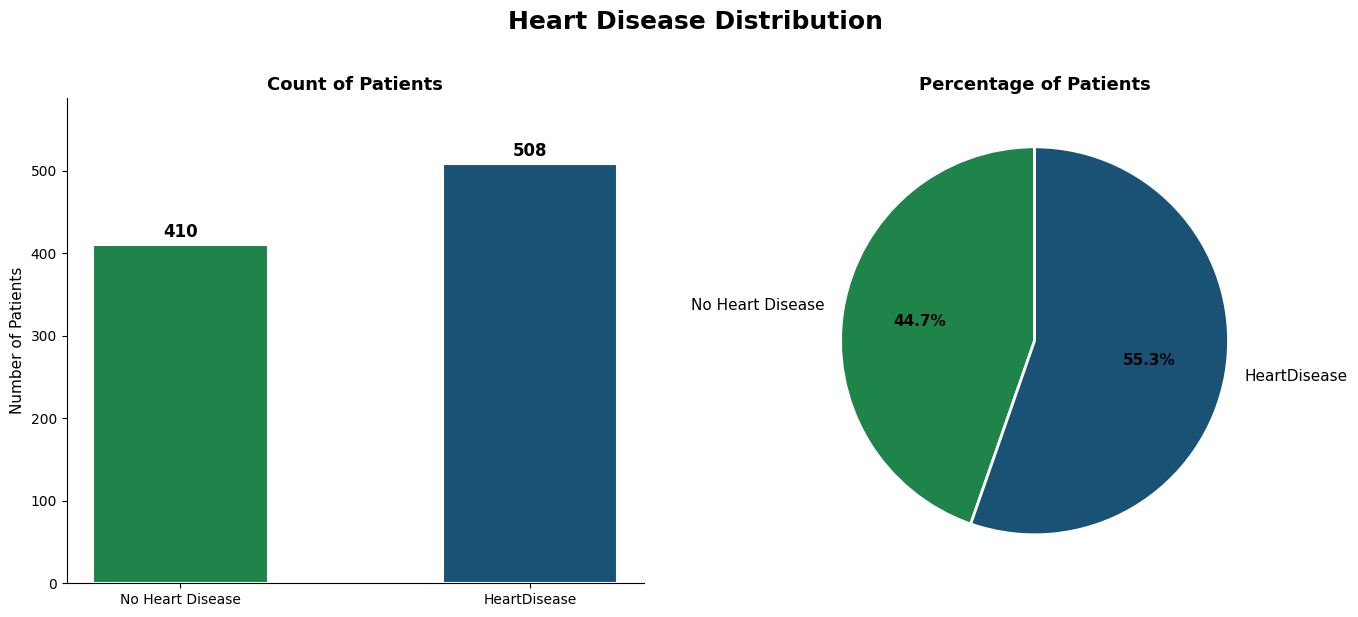

Chart saved!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['No Heart Disease', 'HeartDisease']
colors =['#1e8449', '#1a5276']
size = df['HeartDisease'].value_counts().sort_index()

fig, axes = plt.subplots(1,2, figsize=(14, 6))
fig.suptitle('Heart Disease Distribution', fontsize =18, fontweight = 'bold', y= 1.02)
bars = axes[0].bar(labels, size, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Count of Patients', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patients', fontsize=11)
axes[0].set_ylim(0, max(size) + 80)
for bar, val in zip(bars, size):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', fontsize=12, fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


wedges, texts, autotexts = axes[1].pie(
    size, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('Percentage of Patients', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")


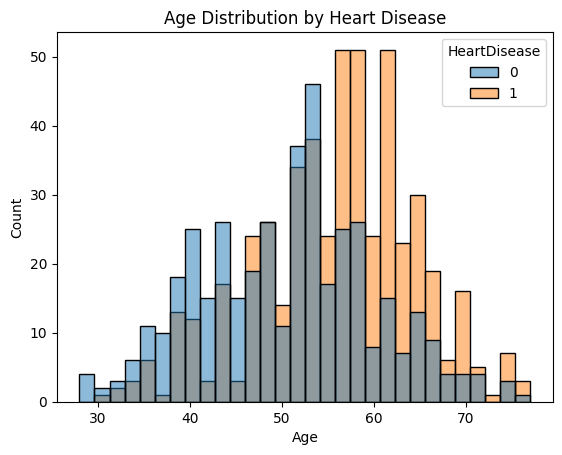

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data=df, x='Age', hue='HeartDisease', bins=30)
plt.title('Age Distribution by Heart Disease')
plt.savefig('Histogram.png', dpi = 150, bbox_inches='tight')
plt.show()


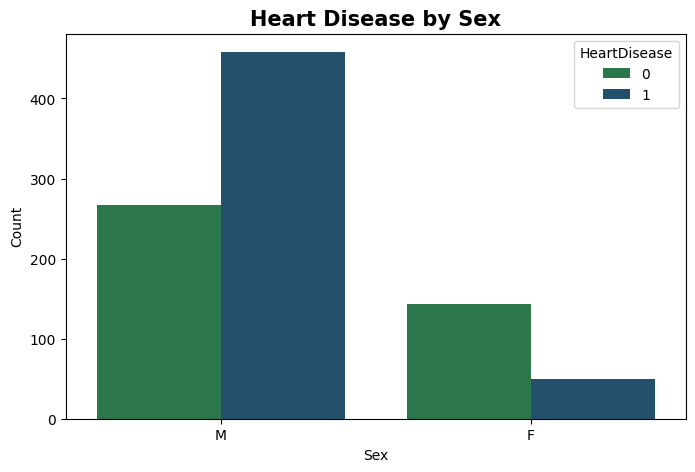

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sex', hue='HeartDisease', palette=['#1e8449', '#1a5276'])
plt.title('Heart Disease by Sex', fontsize=15, fontweight='bold')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.savefig('Sex_bar.png', dpi = 150, bbox_inches = 'tight' )
plt.show()

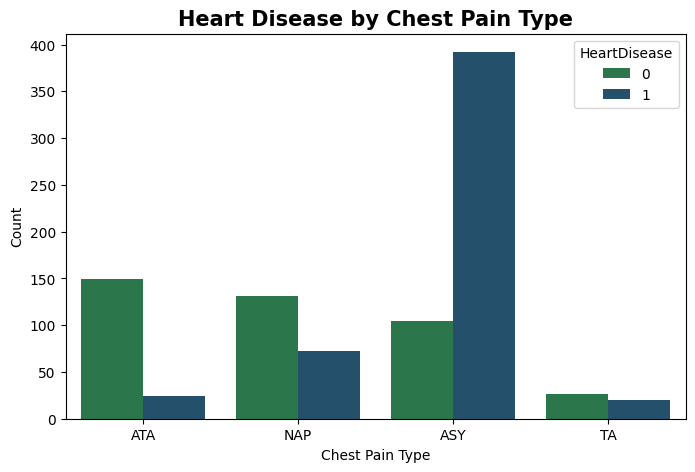

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', palette=['#1e8449', '#1a5276'])
plt.title('Heart Disease by Chest Pain Type', fontsize=15, fontweight='bold')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.savefig('chestPain.png', dpi = 150, bbox_inches='tight')
plt.show()


## 2. Exploratory Data Analysis (EDA)

After SQL analysis I used Python to explore the data deeper
and visualize patterns.

### Key Findings:
 Average age of sick patients is higher than healthy patients
 Males have a much higher heart disease rate than females
 ASY chest pain type is strongly linked to heart disease
 Patients with heart disease tend to have lower MaxHR


In [18]:

df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)
print(df.head())
print(df.columns.tolist())

   Age  Sex  RestingBP  Cholesterol  FastingBS  MaxHR  ExerciseAngina  \
0   40    1        140          289          0    172               0   
1   49    0        160          180          0    156               0   
2   37    1        130          283          0     98               0   
3   48    0        138          214          0    108               1   
4   54    1        150          195          0    122               0   

   Oldpeak  HeartDisease  ChestPainType_ATA  ChestPainType_NAP  \
0      0.0             0               True              False   
1      1.0             1              False               True   
2      0.0             0               True              False   
3      1.5             1              False              False   
4      0.0             0              False               True   

   ChestPainType_TA  RestingECG_Normal  RestingECG_ST  ST_Slope_Flat  \
0             False               True          False          False   
1             False 

In [19]:
X = df.drop('HeartDisease', axis = 1)
y = df['HeartDisease']
print(X.shape)
print(y.shape)

(918, 15)
(918,)


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (734, 15)
X_test shape: (184, 15)
y_train shape: (734,)
y_test shape: (184,)


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaling done!")
print("X_train sample:", X_train[0])

Scaling done!
X_train sample: [-1.24506731  0.54060477 -0.70898547  0.372803    1.84260945  2.28435288
 -0.83846064 -0.09706109 -0.48333575  1.87905939 -0.21350421  0.80817891
 -0.48762079 -1.03325003 -0.84792072]


## 4. Data Preprocessing

Before building the model I split the data into:
 **X** → features (input)
 **y** → target (output)

Then split into training and testing sets:
 **80% training** → 734 patients (model learns from this)
 **20% testing** → 184 patients (model gets tested on this)

Finally applied **Feature Scaling** to normalize all 
numerical features to the same range so no feature 
dominates the model.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = LogisticRegression(random_state= 42)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Logistic Regression ===
Accuracy: 0.85

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



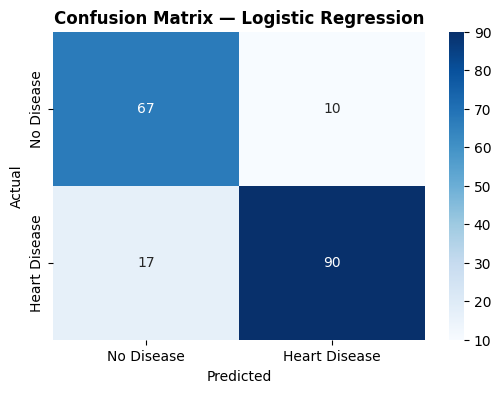

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== Random Forest ===
Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



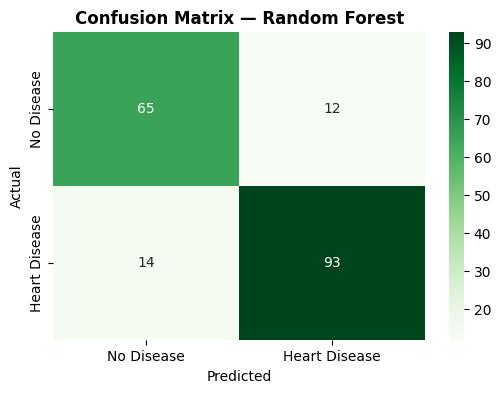

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Build model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== XGBoost ===
Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        77
           1       0.89      0.87      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



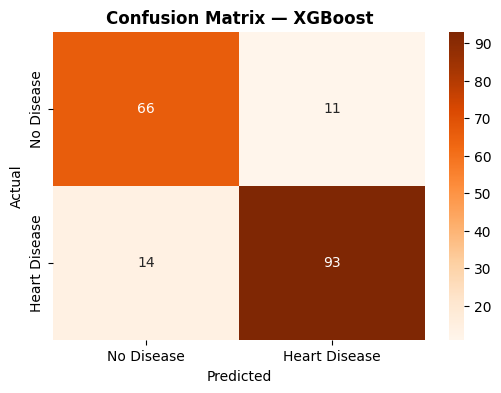

In [25]:
from xgboost import XGBClassifier

# Build model
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')

# Train model
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("=== XGBoost ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Disease', 'Heart Disease'],
            yticklabels=['No Disease', 'Heart Disease'])
plt.title('Confusion Matrix — XGBoost', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

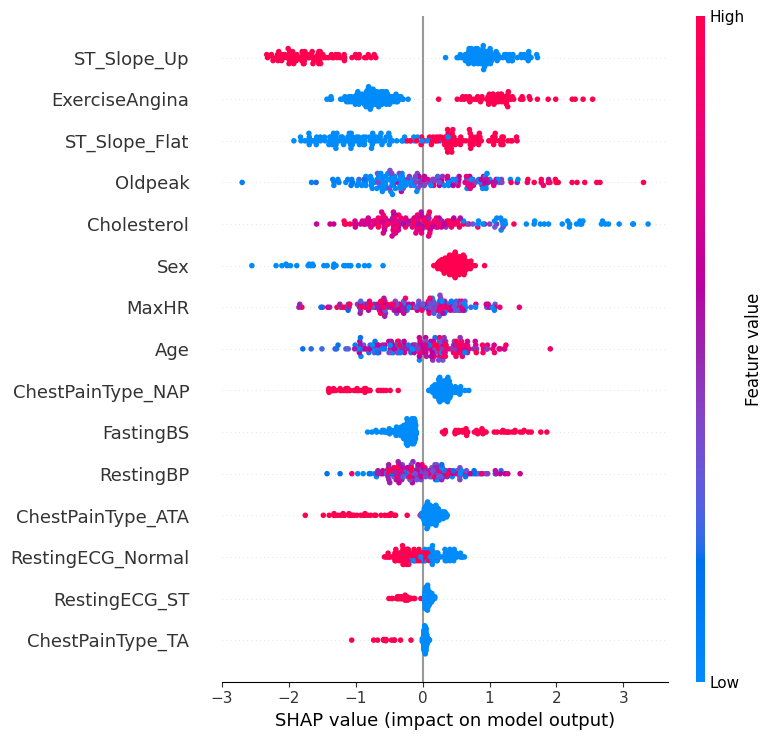

In [ ]:
import shap


explainer = shap.TreeExplainer(xgb_model)


shap_values = explainer.shap_values(X_test)


plt.figure()
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())